In [40]:
print("Hi")

Hi


In [41]:
class Value:
    def __init__(self,data,_children = (),_op = '',label = ''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        s = Value(self.data + other.data,(self,other),'+')
        return s

    def __mul__(self,other):
        s = Value(self.data * other.data,(self,other),'*')
        return s

    def __sub__(self,other):
        s = Value(self.data - other.data,(self,other),"-")
        return s

a = Value(2.0,label='a')
b = Value(3.0,label = 'b')
a,b
c = Value(-10.0,label = 'c')
# a.__add__(b)
k = a*b ; k.label = 'k'
d = k + c ; d.label = 'd'
f = Value(-2.0,label = 'f')
L = d*f; L.label = "L"
print(L)
print(L._prev)
print(L._op)


Value(data=8.0)
{Value(data=-2.0), Value(data=-4.0)}
*


In [42]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label,n.data,n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

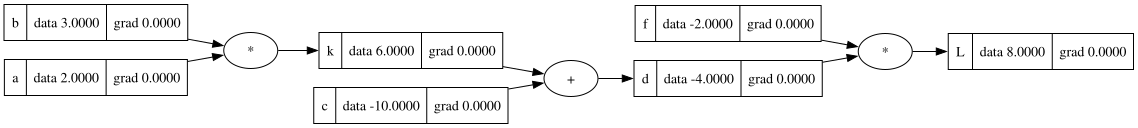

In [38]:
draw_dot(L)

differentiating \
L = f*d \
dL/dd = f \
dL/df = d \
 
dL/dd = -2 \
dL/df = -4

In [45]:
L.grad = 1.0
f.grad = -4
d.grad = -2.0

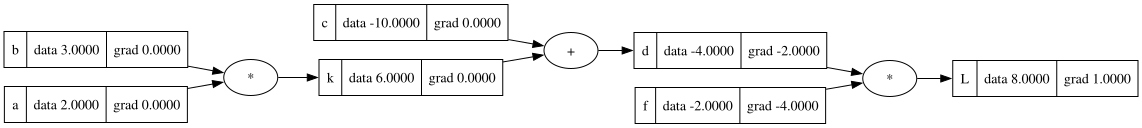

In [46]:
draw_dot(L)

Now we want to obtain : - \
\
dL/dc = ? \
\
We Know : \
\
dL/dc = (dL/dd)*(dd/dc)  \
\
d = k+c \
L = f*d \
dd/dc = 1 \
dd/dk = 1 \
dL/dd = -2 

\
dL/dc = -2 * 1 = -2 \
dL/dk = -2 * 1 = -2 

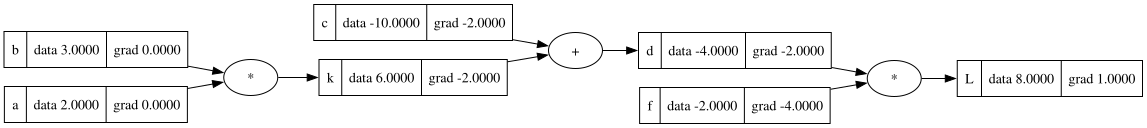

In [47]:
c.grad = -2
k.grad = -2

draw_dot(L)

Now we want to obtain : - \
\
dL/da = ? \
dL/db = ? \
\
We Know : \
\
dL/da = (dL/dd)(dd/dc)*(dc/da)  \
dL/db = (dL/dd)(dd/dc)*(dc/db)  \
\
k = a*b \
dc/da = b \
dd/db = a \

\
dL/da= 3 * 1 * -2  = -6 \
dL/db= 2 * 1 * -2  = -4

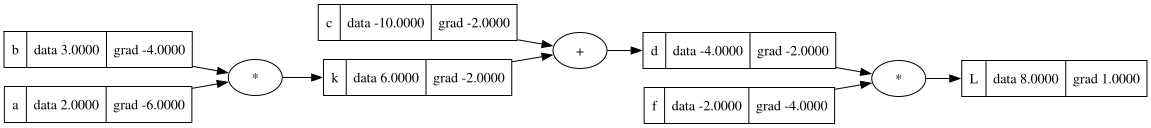

In [50]:
a.grad = -6
b.grad = -4

draw_dot(L)

In [51]:
def lol():
    h = 0.001
    a = Value(2.0,label='a')
    b = Value(3.0,label = 'b')
    c = Value(-10.0,label = 'c')
    k = a*b ; k.label = 'k'
    d = k + c ; d.label = 'd'
    f = Value(-2.0,label = 'f')
    L = d*f; L.label = "L"
    L1 = L.data


    a = Value(2.0,label='a')
    # a.data +=h
    b = Value(3.0,label = 'b')
    b.data +=h

    c = Value(-10.0,label = 'c')
    # c.data += h
    k = a*b ; k.label = 'k'
    d = k + c ; d.label = 'd'
    # d.data +=h
    f = Value(-2.0,label = 'f')
    # f.data +=h
    L = d*f; L.label = "L"
    L2 = L.data

    print((L2-L1)/h)

lol()

-3.9999999999995595
